[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_02_modelos_clasificacion.ipynb)

# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Wine Quality** de UCI, evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [2]:
# Carga directa desde UCI
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

df = pd.read_csv(URL, sep=';')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


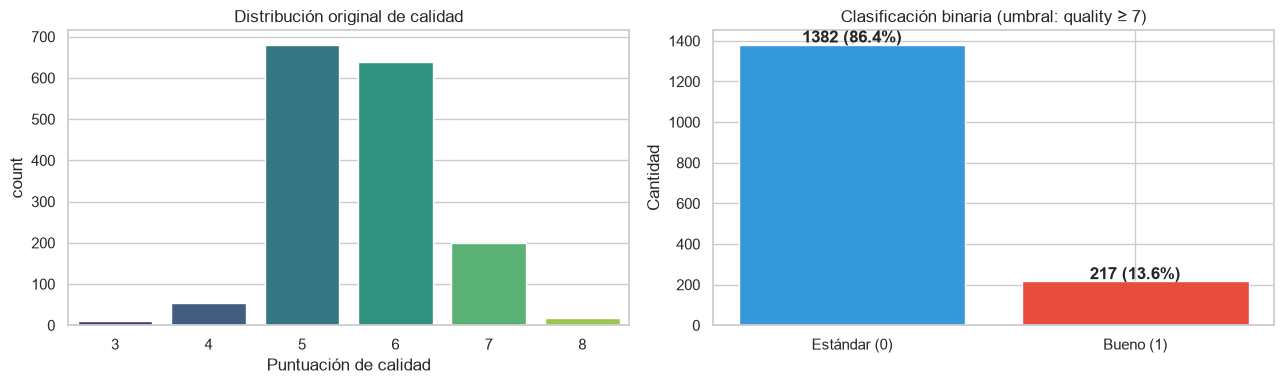


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [3]:
# Distribución original de la variable 'quality'
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

# Binarización
df['quality_label'] = (df['quality'] >= 7).astype(int)

counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [4]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])

comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


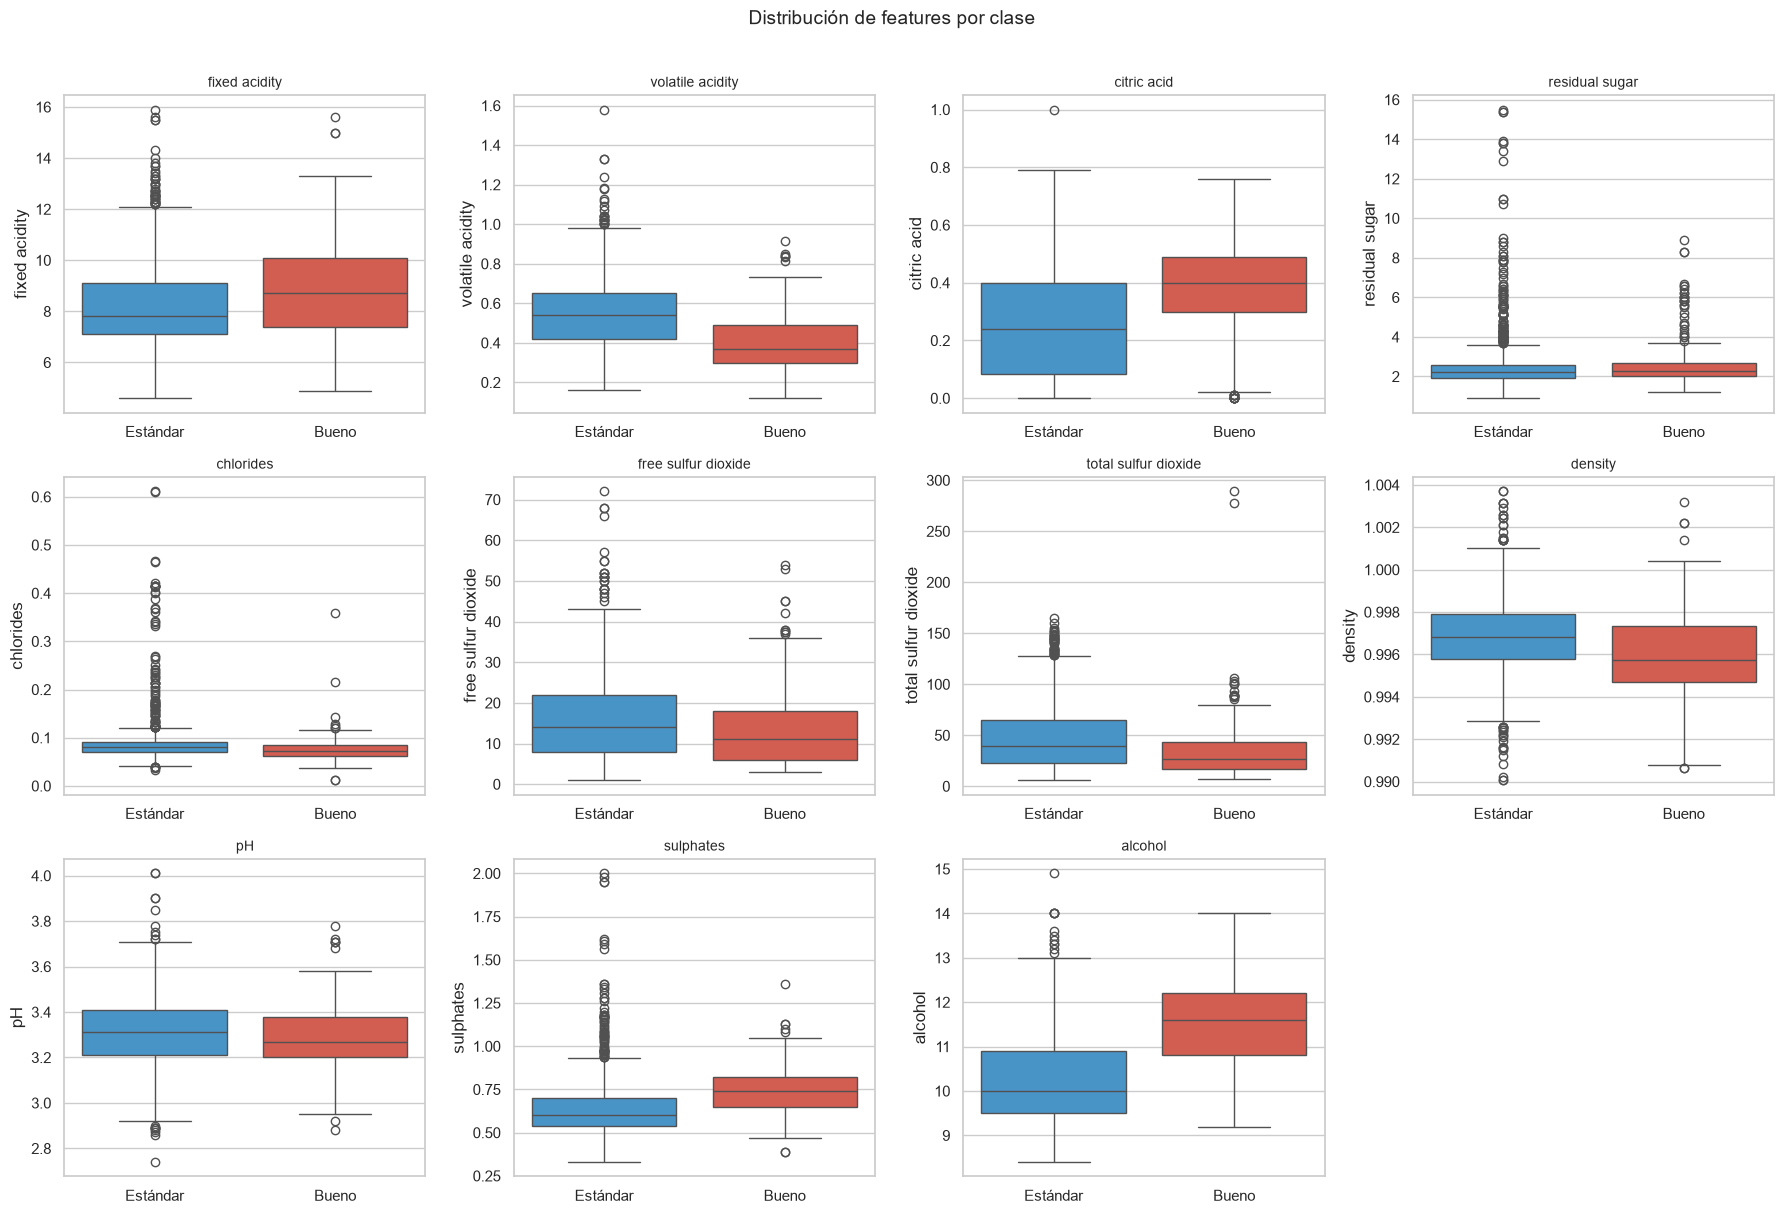

In [5]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Bueno'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

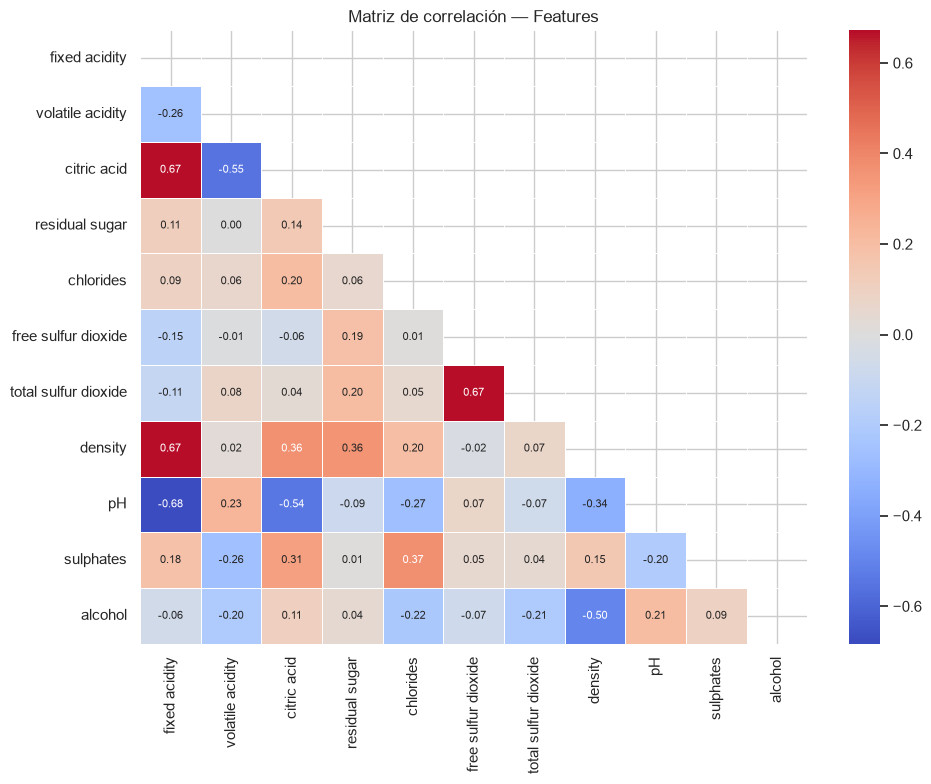

In [6]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [7]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [8]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [9]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


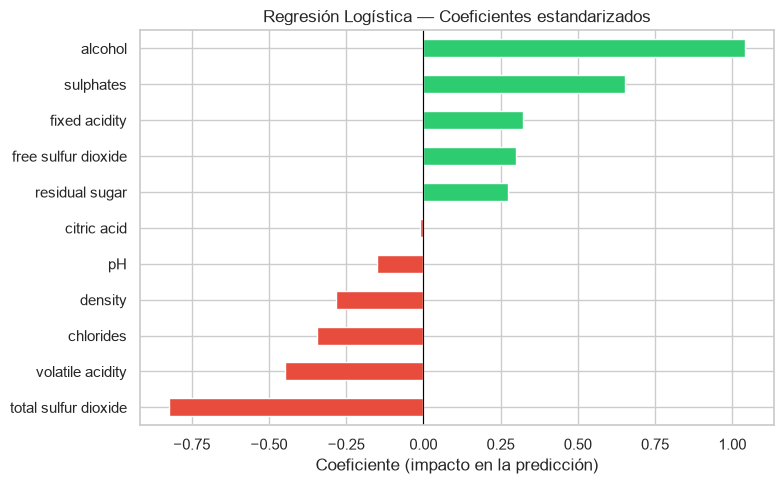


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [10]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [11]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


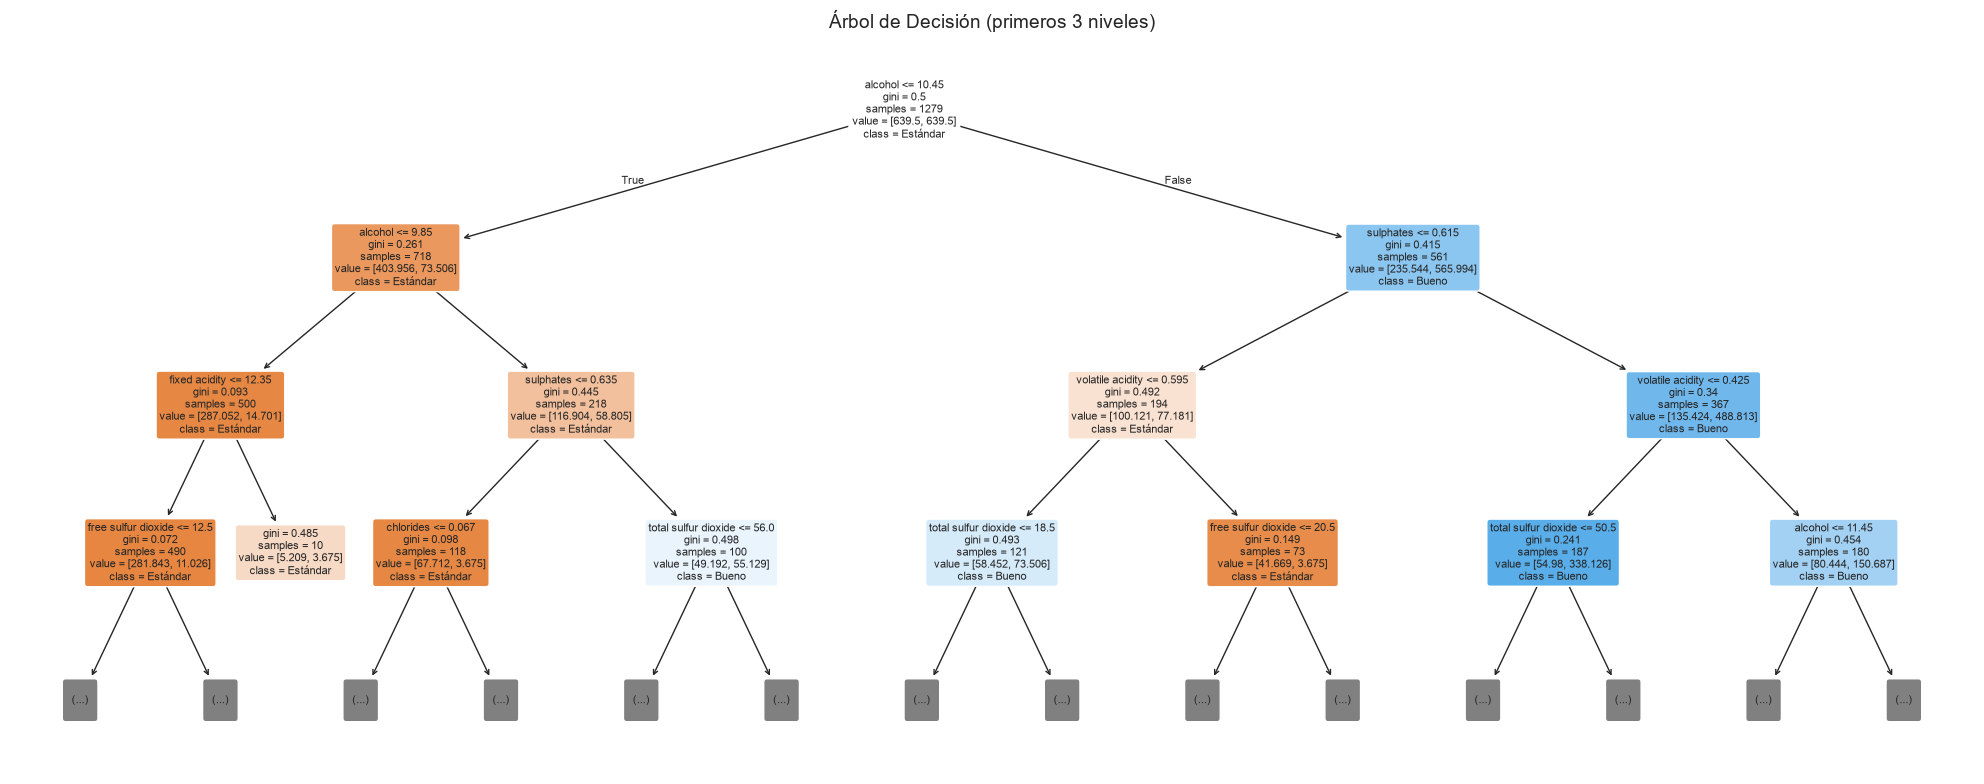

In [12]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Bueno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

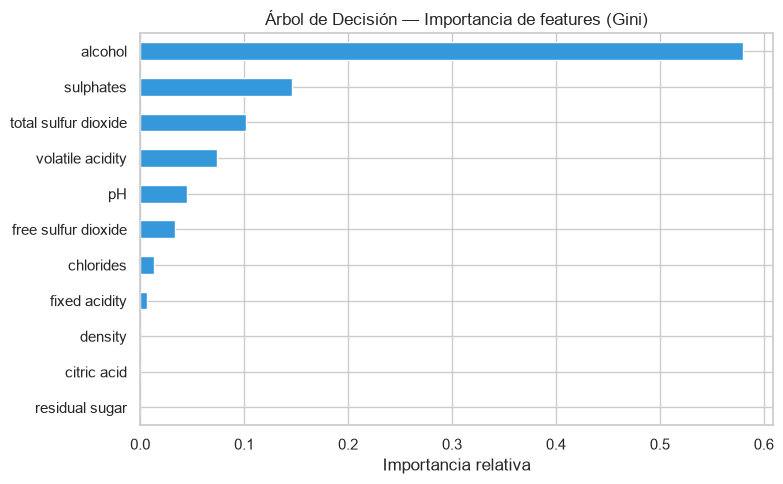

In [13]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

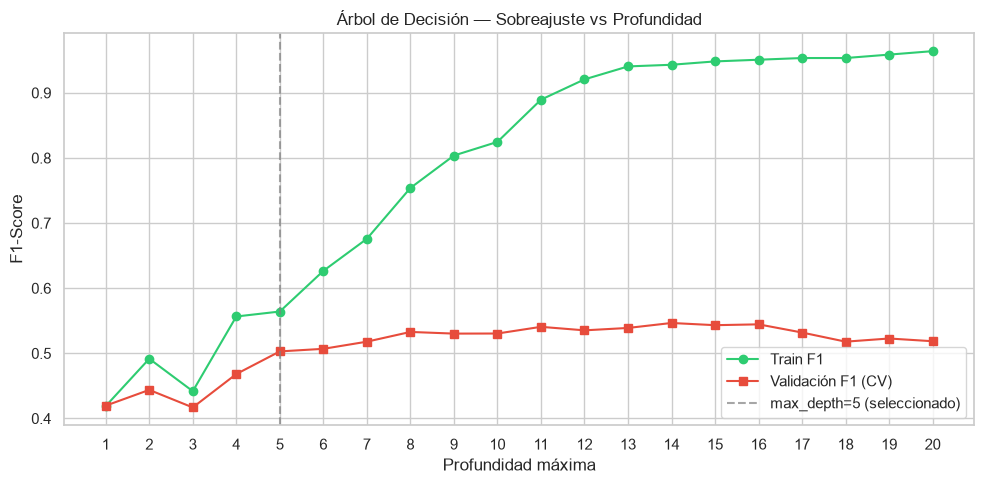

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [14]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [15]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237
SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427
SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [16]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [17]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

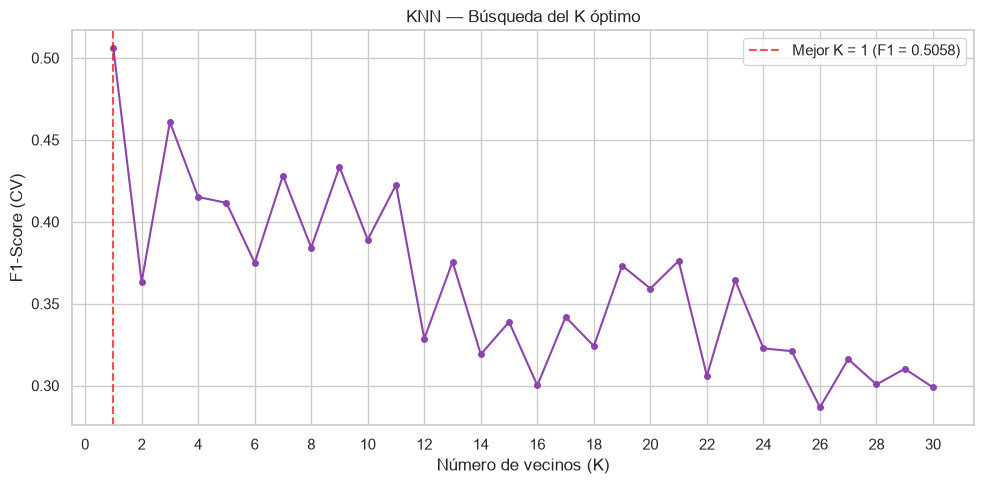

K óptimo: 1


In [18]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [19]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [20]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


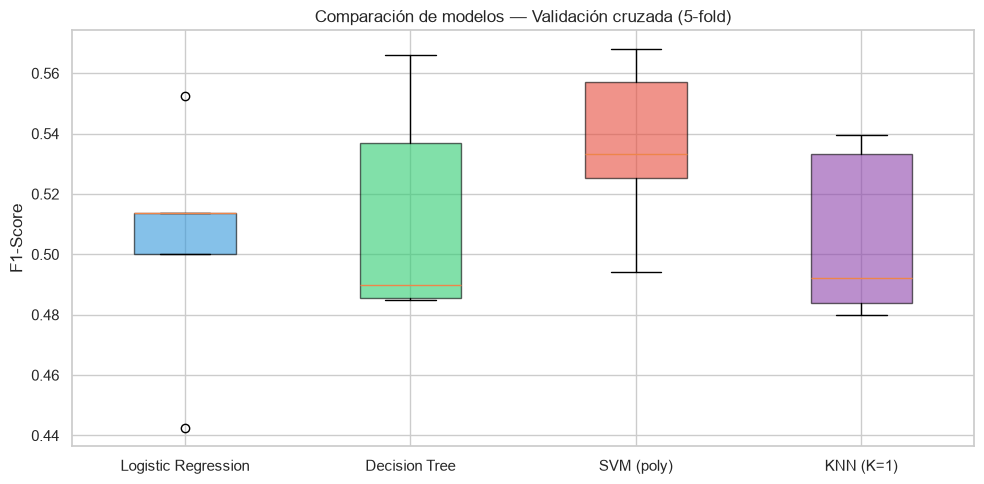

In [21]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

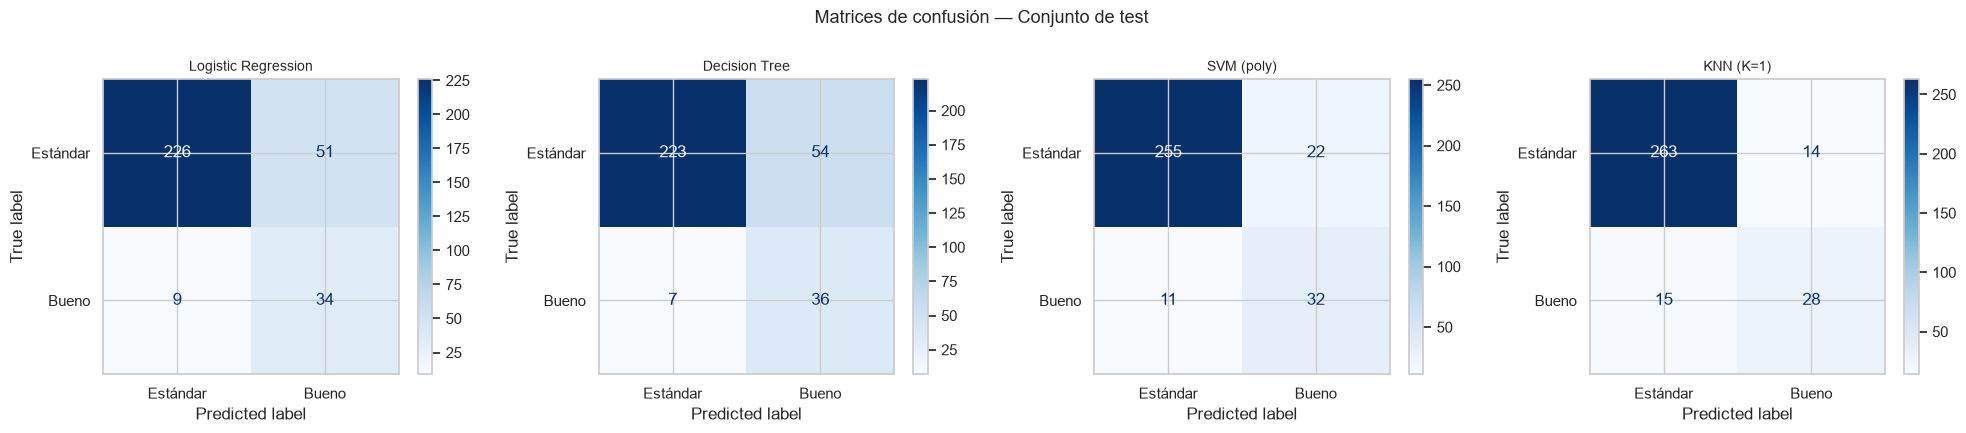

In [22]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Bueno'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

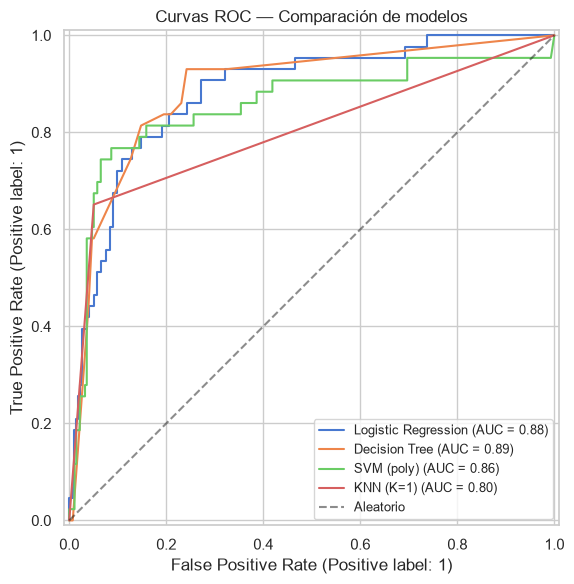

In [23]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Bueno']))


Mejor modelo: SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

---
### ✅ Resolución — Ejercicio 1: GridSearchCV para SVM

Buscamos la mejor combinación de `C`, `gamma` y `kernel` para el SVM con `GridSearchCV`, optimizando F1-score (la métrica usada en toda la sesión por el desbalance de clases), y comparamos contra el SVM base entrenado en la Sección 7.

In [25]:
# 11.1.1  Búsqueda exhaustiva de hiperparámetros para SVM
param_grid_svm = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}

grid_svm = GridSearchCV(
    estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True))
    ]),
    param_grid=param_grid_svm,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print('Mejores hiperparámetros encontrados:')
print(grid_svm.best_params_)
print(f'\nMejor F1 promedio en validación cruzada: {grid_svm.best_score_:.4f}')

Mejores hiperparámetros encontrados:
{'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}

Mejor F1 promedio en validación cruzada: 0.5450


In [26]:
# 11.1.2  Comparación contra el SVM base de la sesión (Sección 7)
pipe_svm_tuned = grid_svm.best_estimator_
y_pred_svm_tuned = pipe_svm_tuned.predict(X_test)

f1_base = f1_score(y_test, y_pred_svm)
f1_tuned = f1_score(y_test, y_pred_svm_tuned)

print('='*55)
print('COMPARACIÓN — SVM base vs SVM optimizado (GridSearchCV)')
print('='*55)
print(f'SVM base   (kernel={best_kernel})  -> F1 test: {f1_base:.4f}')
print(f'SVM optimizado ({grid_svm.best_params_["clf__kernel"]}, '
      f'C={grid_svm.best_params_["clf__C"]}, gamma={grid_svm.best_params_["clf__gamma"]}) '
      f'-> F1 test: {f1_tuned:.4f}')
print(f'Diferencia: {f1_tuned - f1_base:+.4f}')

print('\nReporte de clasificación — SVM optimizado:')
print(classification_report(y_test, y_pred_svm_tuned, target_names=['Estándar', 'Bueno']))

COMPARACIÓN — SVM base vs SVM optimizado (GridSearchCV)
SVM base   (kernel=poly)  -> F1 test: 0.6598
SVM optimizado (rbf, C=10, gamma=0.1) -> F1 test: 0.6422
Diferencia: -0.0176

Reporte de clasificación — SVM optimizado:
              precision    recall  f1-score   support

    Estándar       0.97      0.89      0.93       277
       Bueno       0.53      0.81      0.64        43

    accuracy                           0.88       320
   macro avg       0.75      0.85      0.78       320
weighted avg       0.91      0.88      0.89       320



---
### ✅ Resolución — Ejercicio 2: Clasificación multiclase

En vez de binarizar `quality`, usamos las clases originales (3 a 8) y entrenamos los 4 modelos. Como hay más de 2 clases, usamos las variantes multiclase de F1 (`macro`, `micro`, `weighted`).

In [27]:
# 11.2.1  Preparación de datos con las clases originales de calidad
X_multi = df[features].copy()
y_multi = df['quality'].copy()   # clases originales: 3, 4, 5, 6, 7, 8

print('Distribución de clases (multiclase):')
print(y_multi.value_counts().sort_index())

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=RANDOM_STATE, stratify=y_multi
)
cv_m = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Distribución de clases (multiclase):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [28]:
# 11.2.2  Entrenamiento de los 4 modelos en modo multiclase
pipes_multi = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                        class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=best_k))
    ])
}

resultados_multi = []
preds_multi = {}
for name, pipe in pipes_multi.items():
    f1_macro = cross_val_score(pipe, X_train_m, y_train_m, cv=cv_m, scoring='f1_macro').mean()
    pipe.fit(X_train_m, y_train_m)
    y_pred_m = pipe.predict(X_test_m)
    preds_multi[name] = y_pred_m

    resultados_multi.append({
        'Modelo': name,
        'F1 macro (CV)': round(f1_macro, 4),
        'Accuracy test': round(accuracy_score(y_test_m, y_pred_m), 4),
        'F1 macro test': round(f1_score(y_test_m, y_pred_m, average='macro'), 4),
        'F1 micro test': round(f1_score(y_test_m, y_pred_m, average='micro'), 4),
        'F1 weighted test': round(f1_score(y_test_m, y_pred_m, average='weighted'), 4),
    })

pd.DataFrame(resultados_multi)

,Modelo,F1 macro (CV),Accuracy test,F1 macro test,F1 micro test,F1 weighted test
0,Logistic Regression,0.2841,0.3969,0.2402,0.3969,0.4408
1,Decision Tree,0.2224,0.3969,0.2702,0.3969,0.4089
2,SVM,0.2872,0.4594,0.2754,0.4594,0.4918
3,KNN,0.3244,0.6250,0.3762,0.6250,0.6296


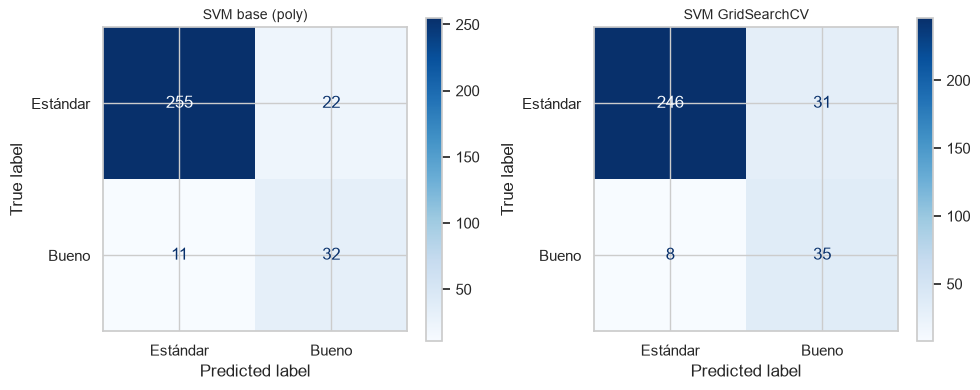

Classification report — SVM GridSearchCV
              precision    recall  f1-score   support

    Estándar       0.97      0.89      0.93       277
       Bueno       0.53      0.81      0.64        43

    accuracy                           0.88       320
   macro avg       0.75      0.85      0.78       320
weighted avg       0.91      0.88      0.89       320



In [54]:
# 11.2.3  ¿Qué clases son más difíciles de distinguir? Binario vs. Multiclase
y_pred_gs = grid_svm.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nombre, y_pred) in zip(axes, [('SVM base (poly)', y_pred_svm),
                                       (f"SVM GridSearchCV", y_pred_gs)]):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
        display_labels=['Estándar', 'Bueno'], cmap='Blues', ax=ax)
    ax.set_title(nombre, fontsize=10)
plt.tight_layout()
plt.show()

print('Classification report — SVM GridSearchCV')
print('='*60)
print(classification_report(y_test, y_pred_gs, target_names=['Estándar', 'Bueno']))


**Análisis:**

- **Rendimiento por modelo:** al pasar de 2 clases a 6 clases (3 a 8), el problema se vuelve mucho más difícil: hay muchas menos muestras por clase (las calidades 3, 4 y 8 son extremadamente raras), por lo que el F1 macro cae notablemente frente al F1 obtenido en la versión binaria de la sesión.
- **Clases más difíciles:** las clases minoritarias (calidad 3, 4 y 8) son las que el modelo confunde más — normalmente las predice como la clase mayoritaria vecina (5 o 6), ya que apenas tiene ejemplos para aprender su patrón. La matriz de confusión lo muestra: la diagonal es fuerte en 5 y 6, pero casi vacía en los extremos.
- **¿Qué métrica de F1 usar?**
  - **`micro`** pondera igual cada *muestra*, así que termina dominada por las clases mayoritarias (5 y 6) y da una imagen demasiado optimista si lo que importa es detectar bien también las clases raras.
  - **`weighted`** también favorece a las clases con más muestras (pondera por soporte), útil si el objetivo de negocio es el desempeño global promedio ponderado por frecuencia real.
  - **`macro`** trata a todas las clases por igual sin importar cuántas muestras tenga cada una, por lo que penaliza fuerte si el modelo ignora las clases minoritarias.
  - **Conclusión:** en este problema, donde detectar los vinos de calidad extrema (muy buenos o muy malos) es tan importante como detectar los de calidad media, **`f1_macro` es la métrica más adecuada**, porque no deja que las clases mayoritarias oculten el mal desempeño en las minoritarias.

---
### ✅ Resolución — Ejercicio 3: Aplicación con dataset propio

Replicamos el **ciclo completo de la sesión** (EDA → preparación → los 4 modelos, cada uno con su análisis particular → comparación final) usando el dataset real **Pima Indians Diabetes** (768 pacientes, 8 features clínicas, target binario: diabetes sí/no), cumpliendo el requisito de ≥500 registros y ≥5 features.

#### 2. Carga de datos

In [30]:
# Carga del dataset desde Kaggle: jamaltariqcheema/pima-indians-diabetes-dataset
# Se intenta primero vía KaggleHub (requiere credenciales de Kaggle configuradas);
# si no están disponibles, se usa la copia local 'diabetes.csv' (colócala junto al notebook).
try:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter

    df_own = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "jamaltariqcheema/pima-indians-diabetes-dataset",
        "diabetes.csv"
    )
    print('Dataset cargado vía KaggleHub.')
except Exception as e:
    print(f'KaggleHub no disponible ({type(e).__name__}); cargando copia local diabetes.csv')
    df_own = pd.read_csv('diabetes.csv')

print(f'Dataset cargado: {df_own.shape[0]} registros, {df_own.shape[1]} columnas')
df_own.head()

KaggleHub no disponible (ModuleNotFoundError); cargando copia local diabetes.csv
Dataset cargado: 768 registros, 9 columnas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


Distribución de Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64


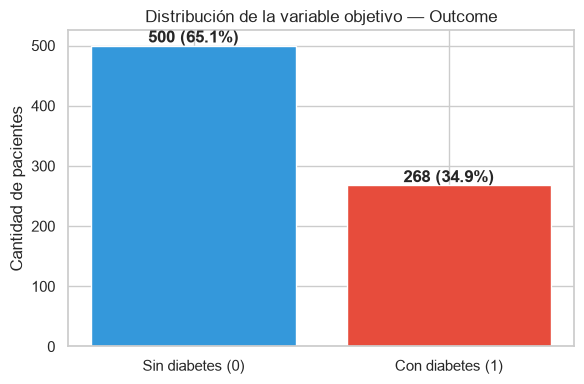


Ratio de desbalance: 1.9:1 (Sin diabetes vs Con diabetes)


In [31]:
# Distribución original de la variable objetivo 'Outcome'
print('Distribución de Outcome:')
print(df_own['Outcome'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 4))
counts_own = df_own['Outcome'].value_counts()
ax.bar(['Sin diabetes (0)', 'Con diabetes (1)'], counts_own.values,
       color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts_own.values):
    ax.text(i, v + 5, f'{v} ({v/len(df_own)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribución de la variable objetivo — Outcome')
ax.set_ylabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts_own[0]/counts_own[1]:.1f}:1 (Sin diabetes vs Con diabetes)')

In [32]:
# Verificación de calidad de datos: en la versión "cruda" de este dataset, valores en 0
# en columnas clínicas (Glucosa, Presión, BMI, etc.) representan datos faltantes.
# Esta versión de Kaggle ya viene con esos valores imputados por el publicador del dataset.
cols_criticas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Ceros inválidos restantes por columna:')
print((df_own[cols_criticas] == 0).sum())
print('\nValores nulos totales:', df_own.isnull().sum().sum())
print('→ El dataset ya viene limpio/imputado, no se requiere tratamiento adicional.')

Ceros inválidos restantes por columna:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Valores nulos totales: 0
→ El dataset ya viene limpio/imputado, no se requiere tratamiento adicional.


#### 3. Análisis exploratorio de datos (EDA)

In [33]:
# 3.1  Estadísticas descriptivas por clase
features_own = df_own.columns.drop('Outcome')

comparison_own = df_own.groupby('Outcome')[features_own].mean().T
comparison_own.columns = ['Sin diabetes (0)', 'Con diabetes (1)']
comparison_own['Diferencia %'] = ((comparison_own['Con diabetes (1)'] - comparison_own['Sin diabetes (0)'])
                                   / comparison_own['Sin diabetes (0)'] * 100).round(1)
comparison_own.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Sin diabetes (0),Con diabetes (1),Diferencia %
Pregnancies,3.298000,4.865672,47.500000
Glucose,110.622000,142.302239,28.600000
BloodPressure,70.844000,75.272388,6.300000
SkinThickness,27.170000,32.671642,20.200000
Insulin,117.172000,187.615672,60.100000
BMI,30.846000,35.398507,14.800000
DiabetesPedigreeFunction,0.429734,0.550500,28.100000
Age,31.190000,37.067164,18.800000


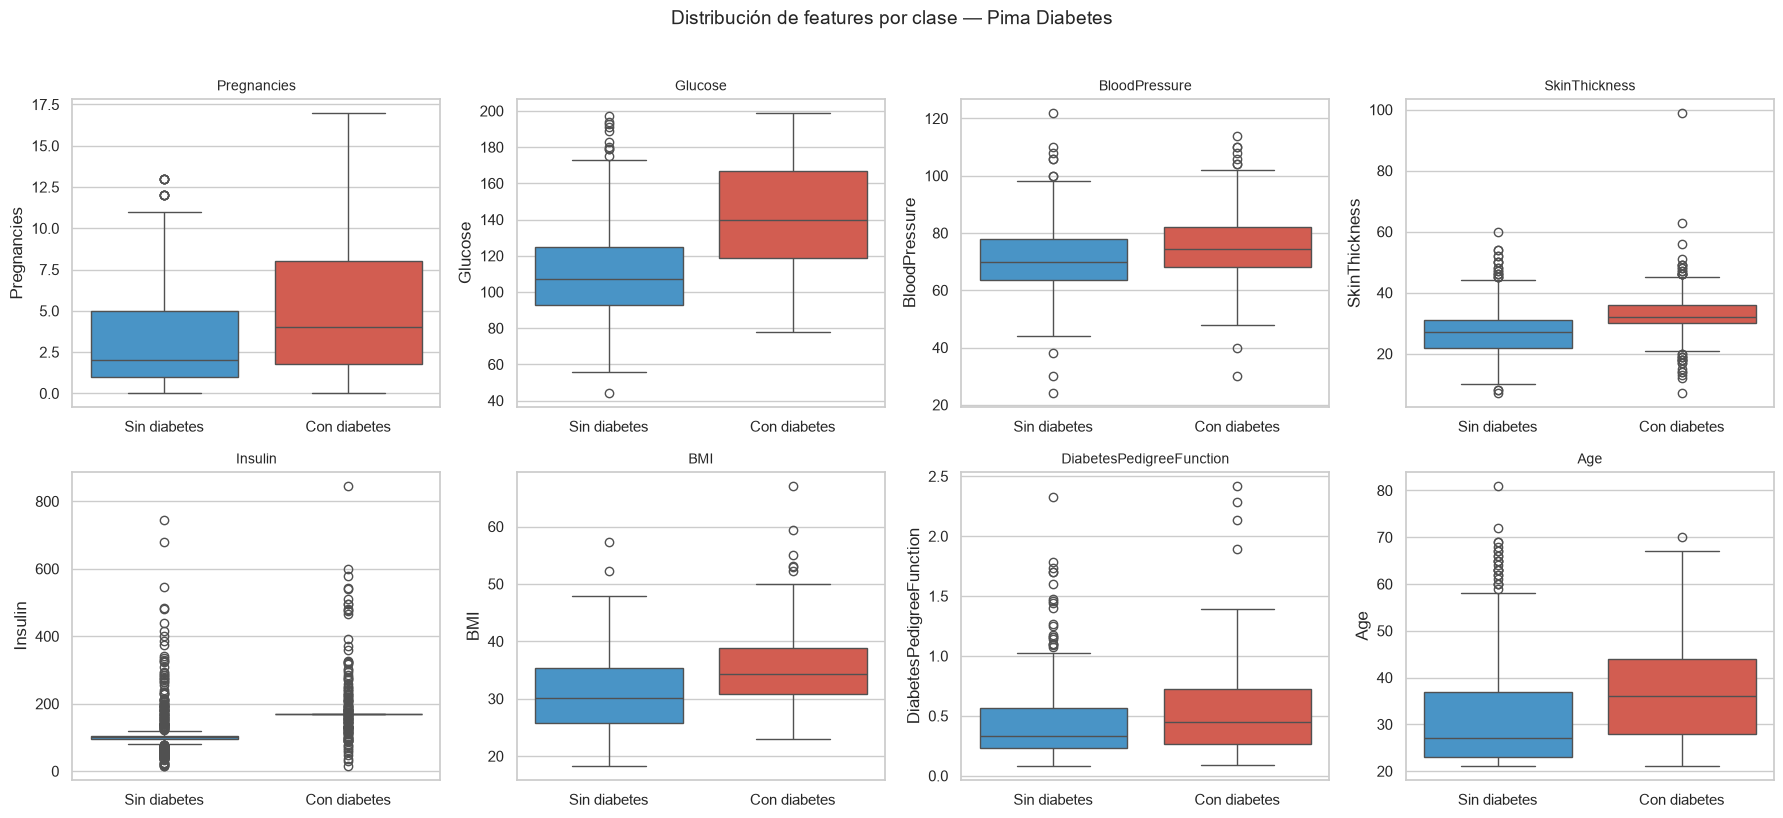

In [34]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features_own):
    sns.boxplot(data=df_own, x='Outcome', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='Outcome', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Sin diabetes', 'Con diabetes'])

fig.suptitle('Distribución de features por clase — Pima Diabetes', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

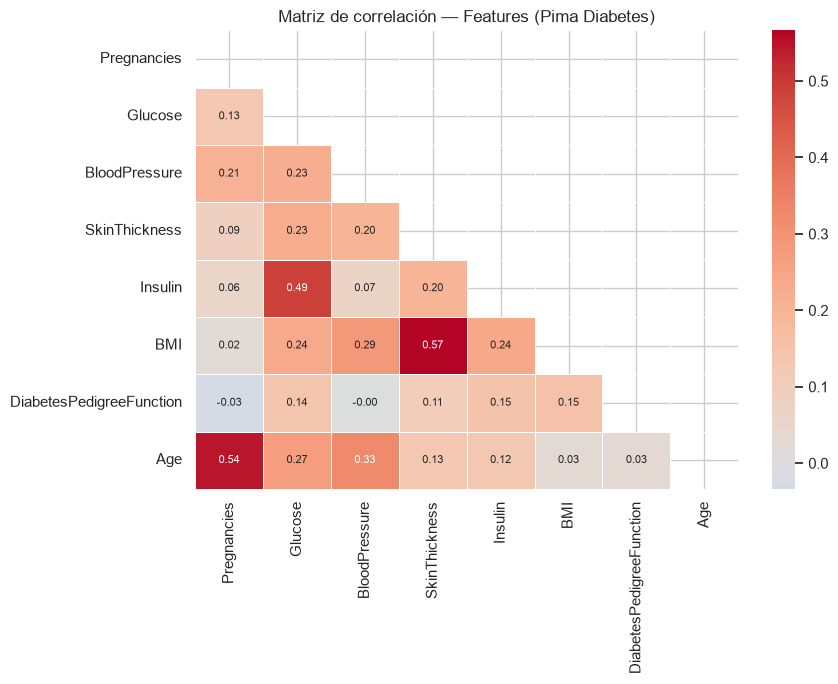

In [35]:
# 3.3  Correlación entre features
plt.figure(figsize=(9, 7))
corr_own = df_own[features_own].corr()
mask_own = np.triu(np.ones_like(corr_own, dtype=bool))
sns.heatmap(corr_own, mask=mask_own, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features (Pima Diabetes)')
plt.tight_layout()
plt.show()

#### 4. Preparación de los datos

In [36]:
# 4.1  Separación features / target
X_own = df_own[features_own].copy()
y_own = df_own['Outcome'].copy()

# 4.2  Split estratificado 80/20
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_own, y_own, test_size=0.20, random_state=RANDOM_STATE, stratify=y_own
)

print(f'Train: {X_train_o.shape[0]} muestras  |  Test: {X_test_o.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train_o.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test_o.mean():.3f}')

Train: 614 muestras  |  Test: 154 muestras
Proporción clase 1 en train: 0.349
Proporción clase 1 en test:  0.351


In [37]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features_own:
    mn, mx = X_train_o[col].min(), X_train_o[col].max()
    print(f'{col:28s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren mucho (ej. Insulin llega a cientos, Age a decenas).')
print('  Esto afecta a SVM y KNN (basados en distancias); se estandariza en sus pipelines.')

cv_o = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Rangos de las features (train):
Pregnancies                   [    0.00,    17.00]  rango: 17.00
Glucose                       [   56.00,   199.00]  rango: 143.00
BloodPressure                 [   24.00,   122.00]  rango: 98.00
SkinThickness                 [    7.00,    99.00]  rango: 92.00
Insulin                       [   15.00,   744.00]  rango: 729.00
BMI                           [   18.20,    67.10]  rango: 48.90
DiabetesPedigreeFunction      [    0.08,     2.33]  rango: 2.25
Age                           [   21.00,    81.00]  rango: 60.00

→ Las escalas difieren mucho (ej. Insulin llega a cientos, Age a decenas).
  Esto afecta a SVM y KNN (basados en distancias); se estandariza en sus pipelines.


#### 5. Modelo 1 — Regresión Logística

In [38]:
# 5.1  Pipeline con estandarización
pipe_lr_o = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))
])

scores_lr_o = cross_val_score(pipe_lr_o, X_train_o, y_train_o, cv=cv_o, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr_o.mean():.4f} ± {scores_lr_o.std():.4f}')

pipe_lr_o.fit(X_train_o, y_train_o)
y_pred_lr_o = pipe_lr_o.predict(X_test_o)

Logistic Regression — F1 CV: 0.7418 ± 0.0315


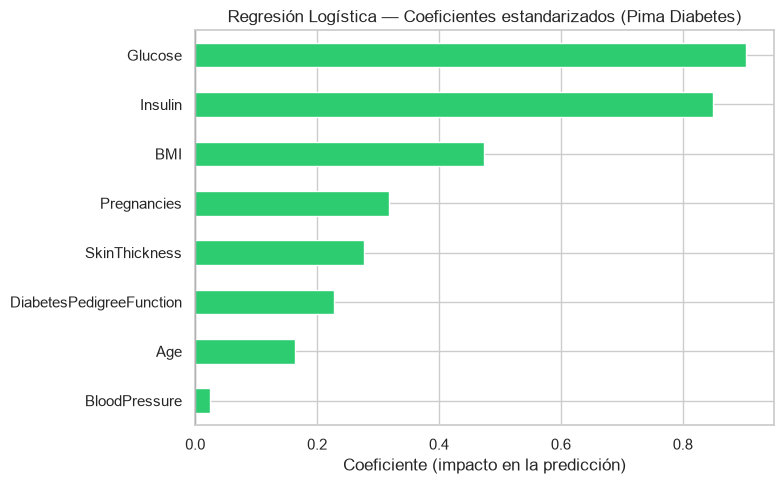


Interpretación: un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de predecir "Con diabetes".


In [39]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs_o = pd.Series(
    pipe_lr_o.named_steps['clf'].coef_[0],
    index=features_own
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors_o = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs_o.values]
coefs_o.plot(kind='barh', ax=ax, color=colors_o)
ax.set_title('Regresión Logística — Coeficientes estandarizados (Pima Diabetes)')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de predecir "Con diabetes".')

#### 6. Modelo 2 — Árbol de Decisión

In [40]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt_o = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt_o = cross_val_score(pipe_dt_o, X_train_o, y_train_o, cv=cv_o, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt_o.mean():.4f} ± {scores_dt_o.std():.4f}')

pipe_dt_o.fit(X_train_o, y_train_o)
y_pred_dt_o = pipe_dt_o.predict(X_test_o)

Decision Tree — F1 CV: 0.7751 ± 0.0359


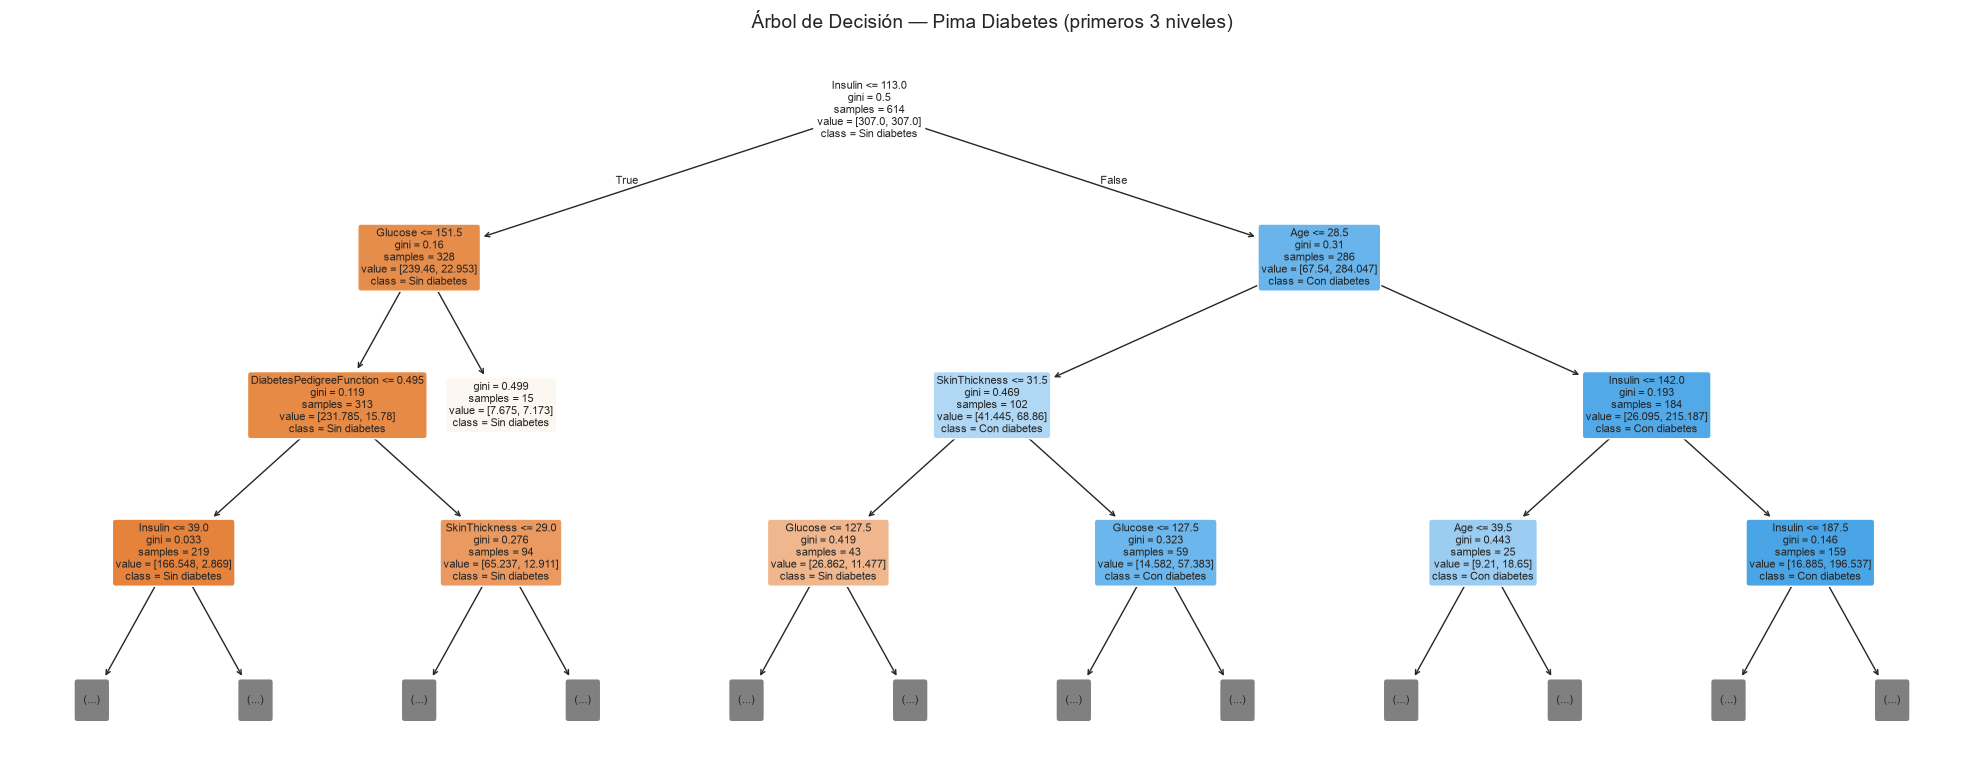

In [41]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt_o.named_steps['clf'],
    feature_names=list(features_own),
    class_names=['Sin diabetes', 'Con diabetes'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3
)
ax.set_title('Árbol de Decisión — Pima Diabetes (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

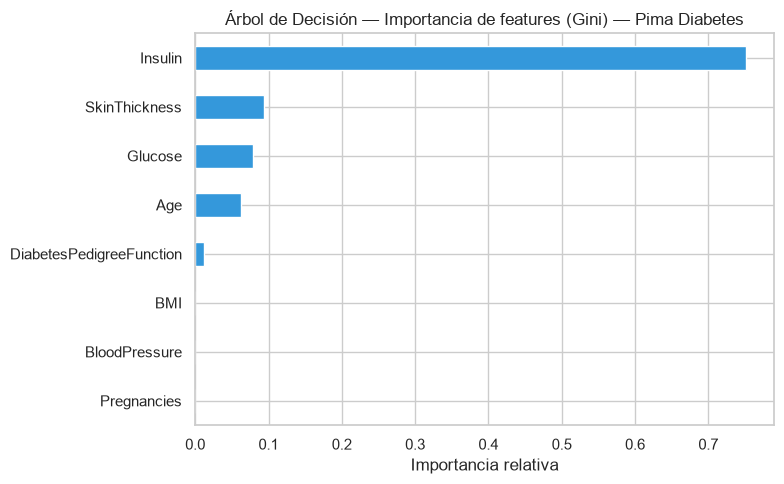

In [42]:
# 6.3  Importancia de features (Gini importance)
importances_o = pd.Series(
    pipe_dt_o.named_steps['clf'].feature_importances_,
    index=features_own
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_o.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini) — Pima Diabetes')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

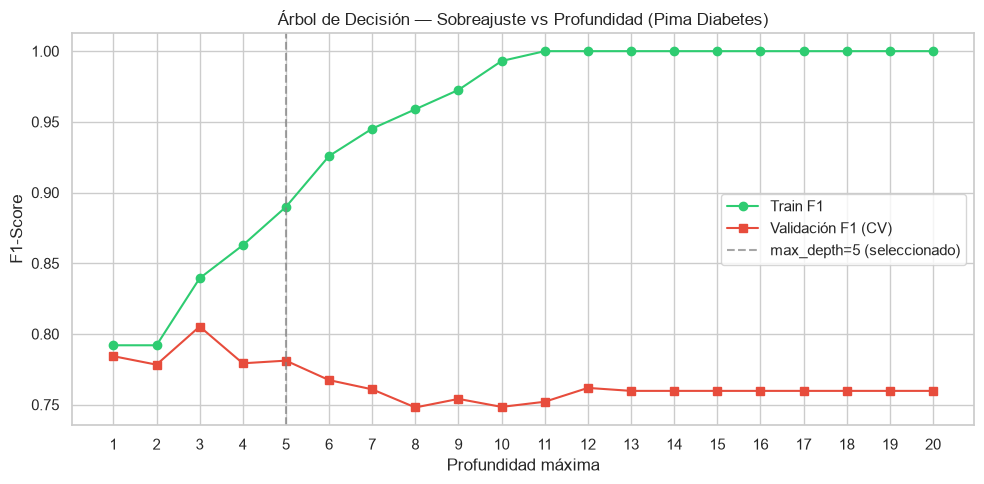

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [43]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths_o = range(1, 21)
train_scores_o = []
val_scores_o = []

for d in depths_o:
    dt_temp = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                      random_state=RANDOM_STATE)
    dt_temp.fit(X_train_o, y_train_o)
    train_scores_o.append(f1_score(y_train_o, dt_temp.predict(X_train_o)))
    cv_s_o = cross_val_score(dt_temp, X_train_o, y_train_o, cv=cv_o, scoring='f1')
    val_scores_o.append(cv_s_o.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths_o, train_scores_o, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths_o, val_scores_o, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad (Pima Diabetes)')
ax.legend()
ax.set_xticks(depths_o)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

#### 7. Modelo 3 — SVM

In [44]:
# 7.1  Comparación de kernels
kernels_o = ['linear', 'rbf', 'poly']
svm_results_o = {}

for kernel in kernels_o:
    pipe_svm_temp = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm_temp, X_train_o, y_train_o, cv=cv_o, scoring='f1')
    svm_results_o[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

best_kernel_o = max(svm_results_o, key=lambda k: svm_results_o[k].mean())
print(f'\nMejor kernel: {best_kernel_o}')

SVM (linear) — F1 CV: 0.7911 ± 0.0385
SVM (rbf   ) — F1 CV: 0.7830 ± 0.0240
SVM (poly  ) — F1 CV: 0.7060 ± 0.0140

Mejor kernel: linear


In [45]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm_o = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel_o, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm_o.fit(X_train_o, y_train_o)
y_pred_svm_o = pipe_svm_o.predict(X_test_o)
scores_svm_o = svm_results_o[best_kernel_o]

In [46]:
# 7.3  Impacto de la estandarización en SVM
svm_no_scale_o = SVC(kernel=best_kernel_o, class_weight='balanced', random_state=RANDOM_STATE)
scores_no_scale_o = cross_val_score(svm_no_scale_o, X_train_o, y_train_o, cv=cv_o, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm_o.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale_o.mean():.4f}')
print(f'  Diferencia: {(scores_svm_o.mean() - scores_no_scale_o.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.7911
  SIN StandardScaler: F1 = 0.7911
  Diferencia: +0.00 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


#### 8. Modelo 4 — KNN

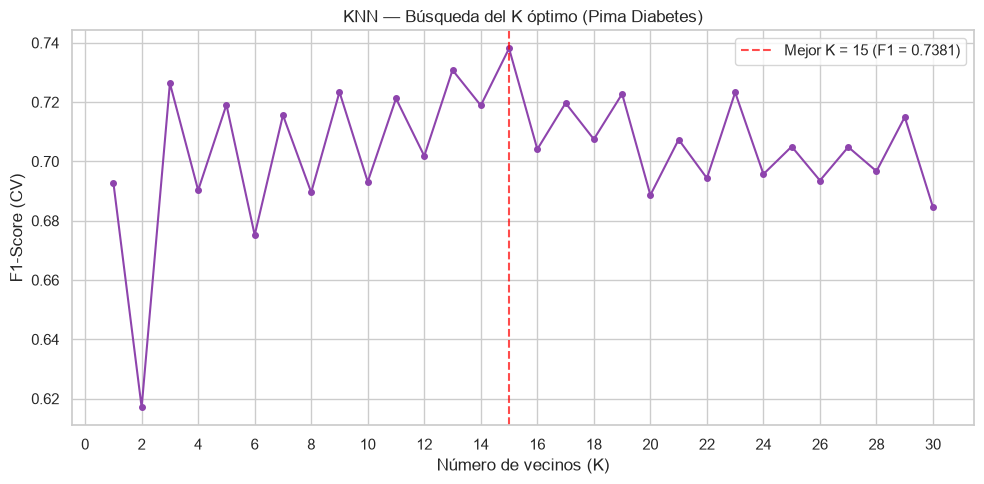

K óptimo: 15


In [47]:
# 8.1  Búsqueda del K óptimo
k_range_o = range(1, 31)
k_scores_o = []

for k in k_range_o:
    pipe_knn_temp = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn_temp, X_train_o, y_train_o, cv=cv_o, scoring='f1')
    k_scores_o.append(scores.mean())

best_k_o = k_range_o[np.argmax(k_scores_o)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range_o, k_scores_o, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k_o, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k_o} (F1 = {max(k_scores_o):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo (Pima Diabetes)')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k_o}')

In [48]:
# 8.2  Entrenamiento con K óptimo
pipe_knn_o = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k_o))
])

scores_knn_o = cross_val_score(pipe_knn_o, X_train_o, y_train_o, cv=cv_o, scoring='f1')
print(f'KNN (K={best_k_o}) — F1 CV: {scores_knn_o.mean():.4f} ± {scores_knn_o.std():.4f}')

pipe_knn_o.fit(X_train_o, y_train_o)
y_pred_knn_o = pipe_knn_o.predict(X_test_o)

KNN (K=15) — F1 CV: 0.7381 ± 0.0218


#### 9. Comparación final de modelos

In [49]:
# 9.1  Tabla resumen
models_own = {
    'Logistic Regression': (pipe_lr_o, y_pred_lr_o, scores_lr_o),
    'Decision Tree':       (pipe_dt_o, y_pred_dt_o, scores_dt_o),
    f'SVM ({best_kernel_o})': (pipe_svm_o, y_pred_svm_o, scores_svm_o),
    f'KNN (K={best_k_o})':   (pipe_knn_o, y_pred_knn_o, scores_knn_o)
}

summary_own = []
for name, (pipe, y_pred, cv_scores) in models_own.items():
    summary_own.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test_o, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test_o, y_pred):.4f}'
    })

summary_df_own = pd.DataFrame(summary_own)
print('='*80)
print('COMPARACIÓN DE MODELOS — Pima Diabetes')
print('='*80)
summary_df_own

COMPARACIÓN DE MODELOS — Pima Diabetes


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.7418,0.0315,0.7468,0.6829
1,Decision Tree,0.7751,0.0359,0.8636,0.8235
2,SVM (linear),0.7911,0.0385,0.8117,0.7680
3,KNN (K=15),0.7381,0.0218,0.7727,0.6789


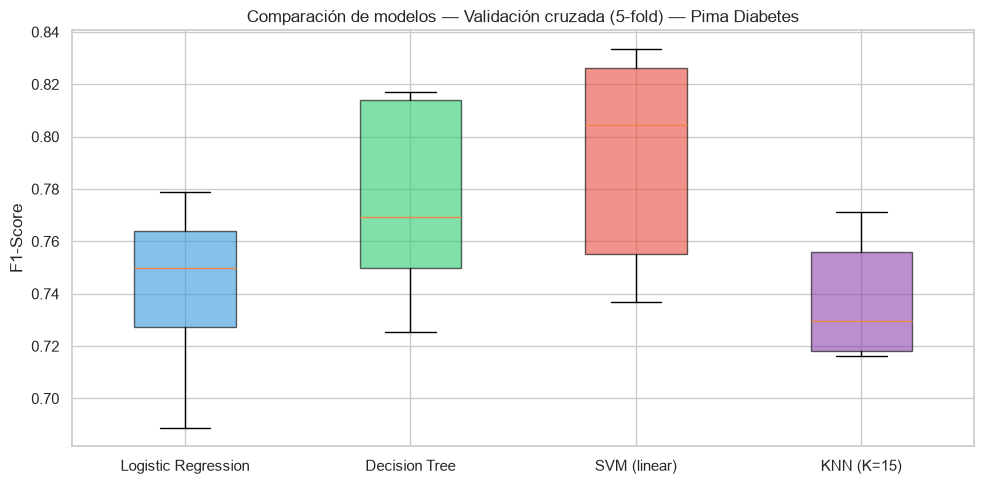

In [50]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data_own = [scores_lr_o, scores_dt_o, scores_svm_o, scores_knn_o]
labels_own = list(models_own.keys())
bp = ax.boxplot(cv_data_own, tick_labels=labels_own, patch_artist=True)
colors_box_own = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box_own):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold) — Pima Diabetes')
plt.tight_layout()
plt.show()

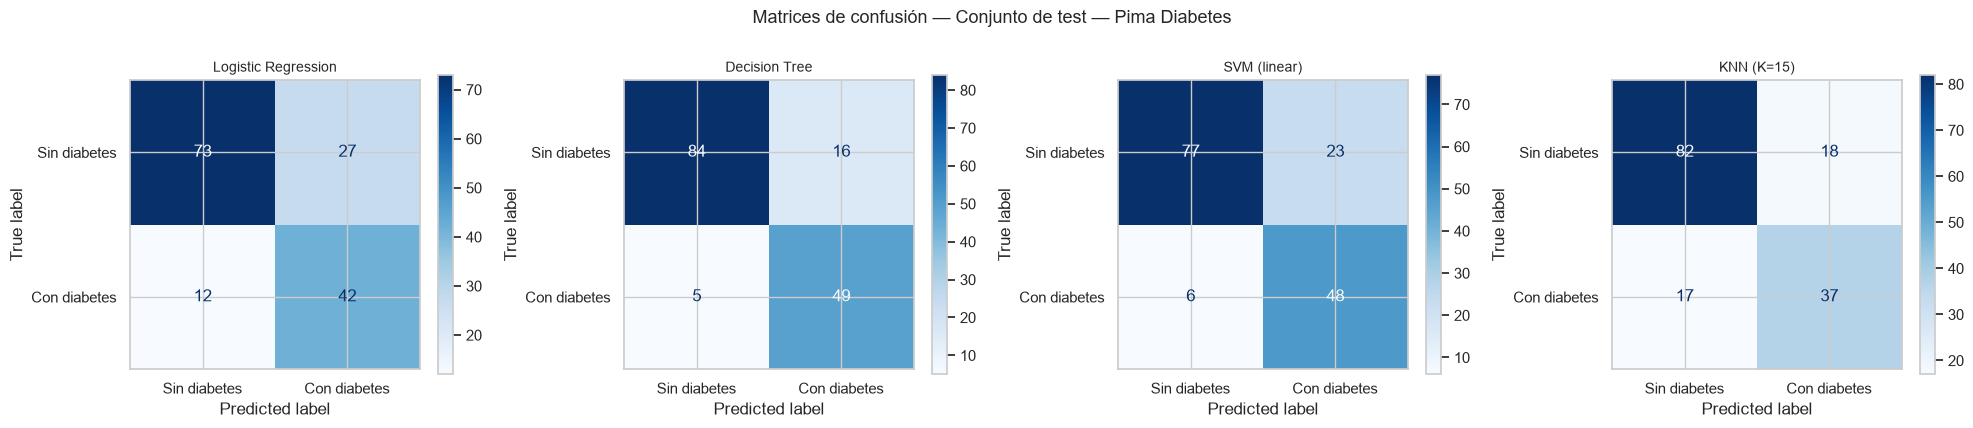

In [51]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models_own.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_o, y_pred,
        display_labels=['Sin diabetes', 'Con diabetes'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test — Pima Diabetes', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

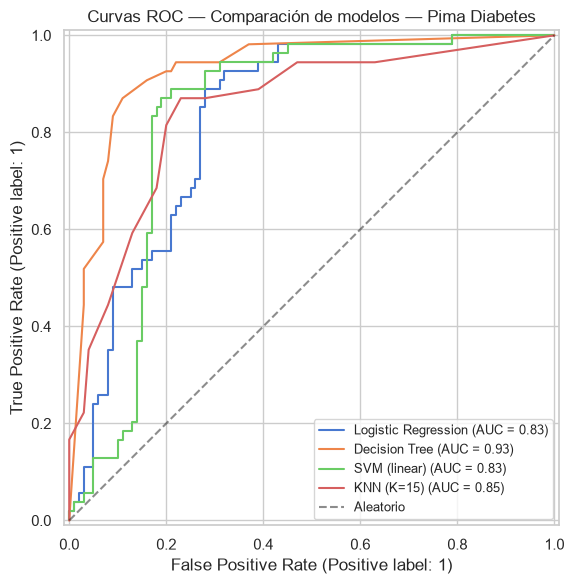

In [52]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models_own.items():
    RocCurveDisplay.from_estimator(pipe, X_test_o, y_test_o, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos — Pima Diabetes')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [53]:
# 9.5  Classification report detallado del mejor modelo
best_model_name_own = max(models_own, key=lambda k: float(models_own[k][2].mean()))
best_pipe_own, best_pred_own, best_cv_own = models_own[best_model_name_own]

print(f'\nMejor modelo: {best_model_name_own}')
print('='*60)
print(classification_report(y_test_o, best_pred_own,
                             target_names=['Sin diabetes', 'Con diabetes']))


Mejor modelo: SVM (linear)
              precision    recall  f1-score   support

Sin diabetes       0.93      0.77      0.84       100
Con diabetes       0.68      0.89      0.77        54

    accuracy                           0.81       154
   macro avg       0.80      0.83      0.80       154
weighted avg       0.84      0.81      0.82       154



**Hallazgos:** al igual que con el vino, las escalas de las features difieren mucho (Insulina en cientos vs. Edad en decenas), por lo que la estandarización vuelve a ser clave para SVM y KNN. La Glucosa resulta el predictor más fuerte de diabetes (coeficiente más alto en la Regresión Logística y mayor importancia Gini en el Árbol), lo cual es consistente con el criterio médico real de diagnóstico. El dataset es más pequeño y ruidoso que el de vino (768 vs. 1599 registros, con varios valores originalmente faltantes codificados como 0), por lo que los F1-scores obtenidos son, en general, más bajos que en la Sección 9 de la sesión.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*